In [10]:
import os
import shutil
import random

print("Mulai membagi dataset...")

# 1. Tentukan folder sumber (mentahan) dan folder tujuan
# SESUAIKAN dengan nama folder tempat kamu menaruh gambar barumu
sumber_real = './DATASET/mentahan_baru/real' 
sumber_fake = './DATASET/mentahan_baru/fake' 

# Ini folder target yang dipakai oleh kodingan AI kamu
folder_tujuan = './DATASET/real_vs_fake/real-vs-fake'

# 2. Bikin folder train, valid, test otomatis kalau belum ada
kategori = ['real', 'fake']
folder_split = ['train', 'valid', 'test']

for split in folder_split:
    for kat in kategori:
        os.makedirs(os.path.join(folder_tujuan, split, kat), exist_ok=True)

# 3. Fungsi robot pemindah
def bagi_dan_pindah(folder_sumber, nama_kategori):
    # Ambil semua nama file dan acak urutannya biar distribusinya adil
    semua_file = os.listdir(folder_sumber)
    random.shuffle(semua_file)
    
    total = len(semua_file)
    batas_train = int(total * 0.80) # 80% untuk latihan
    batas_valid = int(total * 0.90) # 80% + 10% = 90% (sisanya 10% buat test)
    
    # Potong daftarnya
    file_train = semua_file[:batas_train]
    file_valid = semua_file[batas_train:batas_valid]
    file_test = semua_file[batas_valid:]
    
    # Fungsi kecil untuk copy file
    def copy_file(daftar_file, tujuan_split):
        for nama_file in daftar_file:
            asal = os.path.join(folder_sumber, nama_file)
            tujuan = os.path.join(folder_tujuan, tujuan_split, nama_kategori, nama_file)
            shutil.copy(asal, tujuan) # Kita pakai copy agar mentahannya tetap aman!
            
    # Eksekusi!
    copy_file(file_train, 'train')
    copy_file(file_valid, 'valid')
    copy_file(file_test, 'test')
    
    print(f"✅ {nama_kategori.upper()} selesai! Train: {len(file_train)}, Valid: {len(file_valid)}, Test: {len(file_test)}")

# 4. Jalankan robotnya!
bagi_dan_pindah(sumber_real, 'real')
bagi_dan_pindah(sumber_fake, 'fake')

print("\n🎉 PEMBAGIAN DATASET SELESAI! Silakan cek File Explorer kamu.")

Mulai membagi dataset...
✅ REAL selesai! Train: 4864, Valid: 608, Test: 609
✅ FAKE selesai! Train: 4768, Valid: 596, Test: 596

🎉 PEMBAGIAN DATASET SELESAI! Silakan cek File Explorer kamu.


--- Exploratory Data Analysis (EDA) ---

📊 Distribusi untuk TRAIN:
  - real: 4,864 gambar
  - fake: 4,768 gambar
  Total train: 9,632 gambar

📊 Distribusi untuk VALID:
  - real: 608 gambar
  - fake: 596 gambar
  Total valid: 1,204 gambar

📊 Distribusi untuk TEST:
  - real: 609 gambar
  - fake: 596 gambar
  Total test: 1,205 gambar


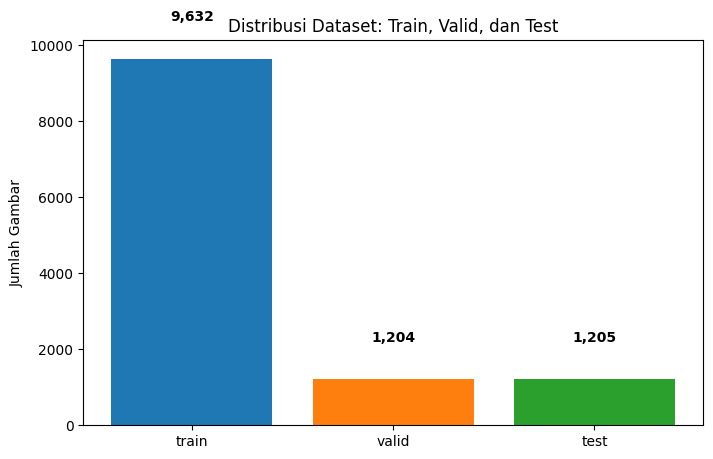

In [11]:
import os
import matplotlib.pyplot as plt

# 1. Sesuaikan path dengan struktur foldermu yang sebenarnya
base_dir = "./DATASET/real_vs_fake/real-vs-fake"

# Kategori folder dan kelas
splits = ['train', 'valid', 'test']
classes = ['real', 'fake']

print("--- Exploratory Data Analysis (EDA) ---")

# Siapkan tempat untuk menyimpan data grafik
plot_data = {'train': 0, 'valid': 0, 'test': 0}

# 2. Menghitung jumlah gambar di setiap folder
for split in splits:
    print(f"\n📊 Distribusi untuk {split.upper()}:")
    total_split = 0
    
    for cls in classes:
        # Menggabungkan path, contoh: ./DATASET/real_vs_fake/real-vs-fake/train/real
        path = os.path.join(base_dir, split, cls)
        
        try:
            count = len(os.listdir(path))
            print(f"  - {cls}: {count:,} gambar")
            total_split += count
        except FileNotFoundError:
            print(f"  - {cls}: ❌ Folder tidak ditemukan di {path}")
            
    plot_data[split] = total_split
    print(f"  Total {split}: {total_split:,} gambar")

# 3. Membuat Grafik untuk Laporan Skripsi
plt.figure(figsize=(8, 5))
plt.bar(plot_data.keys(), plot_data.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Distribusi Dataset: Train, Valid, dan Test")
plt.ylabel("Jumlah Gambar")

# Menambahkan angka di atas bar
for i, v in enumerate(plot_data.values()):
    plt.text(i, v + 1000, f"{v:,}", ha='center', fontweight='bold')

plt.show()

In [12]:
import os
import hashlib
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# 1. Tentukan Path Dataset
base_dir = "./DATASET/real_vs_fake/real-vs-fake"

print("--- Memulai Pengecekan Data Duplikat (MD5 Hashing) ---")

# 2. Kumpulkan semua jalur file gambar terlebih dahulu
all_files = []
for split in ['train', 'valid', 'test']:
    for cls in ['real', 'fake']:
        folder_path = os.path.join(base_dir, split, cls)
        if os.path.exists(folder_path):
            for file_name in os.listdir(folder_path):
                if file_name.endswith(('.jpg', '.jpeg', '.png')):
                    all_files.append(os.path.join(folder_path, file_name))

print(f"Total gambar yang akan dipindai: {len(all_files):,} file")

# 3. Proses mencari 'Sidik Jari' duplikat
hashes = {}
duplicates = []

for file_path in tqdm(all_files, desc="Scanning Images"):
    # Membaca file sebagai byte dan membuat hash MD5
    with open(file_path, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
        
    if file_hash in hashes:
        # Jika hash sudah ada, berarti ini duplikat!
        duplicates.append((file_path, hashes[file_hash]))
    else:
        # Jika belum ada, simpan ke memori
        hashes[file_hash] = file_path

# 4. Laporan Hasil
print("\n--- LAPORAN HASIL PENGECEKAN ---")
if len(duplicates) == 0:
    print("✅ LUAR BIASA! Tidak ditemukan gambar duplikat sama sekali. Dataset kamu sangat bersih!")
else:
    print(f"⚠️ GAWAT! Ditemukan {len(duplicates):,} gambar duplikat!")
    print("Contoh file yang kembar:")
    # Tampilkan 5 contoh duplikat
    for i in range(min(5, len(duplicates))):
        print(f"  [Kembaran {i+1}]")
        print(f"  - File 1: {duplicates[i][0]}")
        print(f"  - File 2: {duplicates[i][1]}")

--- Memulai Pengecekan Data Duplikat (MD5 Hashing) ---
Total gambar yang akan dipindai: 12,041 file


Scanning Images:   0%|          | 0/12041 [00:00<?, ?it/s]


--- LAPORAN HASIL PENGECEKAN ---
✅ LUAR BIASA! Tidak ditemukan gambar duplikat sama sekali. Dataset kamu sangat bersih!


In [13]:
import os

# Sesuaikan path ini dengan folder datasetmu yang ada di screenshot
valid_dir = './DATASET/real_vs_fake/real-vs-fake/valid'
train_dir = './DATASET/real_vs_fake/real-vs-fake/train'

print("Memulai proses pembersihan Data Leakage...")

total_dihapus = 0

# Kita bersihkan di kedua kategori: 'real' dan 'fake'
for kategori in ['real', 'fake']:
    valid_path = os.path.join(valid_dir, kategori)
    train_path = os.path.join(train_dir, kategori)
    
    # Kumpulkan semua nama file yang jadi "soal ujian" (Validasi)
    valid_files = set(os.listdir(valid_path))
    
    terhapus_kategori = 0
    # Cek satu per satu file di folder latihan (Train)
    for file_train in os.listdir(train_path):
        # Jika file latihan ternyata ada di soal ujian, HAPUS!
        if file_train in valid_files:
            file_path_bocor = os.path.join(train_path, file_train)
            os.remove(file_path_bocor)
            terhapus_kategori += 1
            total_dihapus += 1
            
    print(f"✅ Dihapus {terhapus_kategori} gambar duplikat dari folder train/{kategori}")

print(f"\n🎉 PEMBERSIHAN SELESAI! Total {total_dihapus} file bocor berhasil dihapus dari folder train.")

Memulai proses pembersihan Data Leakage...
✅ Dihapus 0 gambar duplikat dari folder train/real
✅ Dihapus 0 gambar duplikat dari folder train/fake

🎉 PEMBERSIHAN SELESAI! Total 0 file bocor berhasil dihapus dari folder train.


In [14]:
from PIL import Image
import os
from tqdm.notebook import tqdm

print("--- Memulai Pengecekan File Gambar Corrupt (Rusak) ---")

corrupted_files = []

# Menggunakan list 'all_files' dari kodingan MD5 sebelumnya
for file_path in tqdm(all_files, desc="Memeriksa Integritas Gambar"):
    try:
        # Mencoba membuka dan memverifikasi header file gambar
        img = Image.open(file_path)
        img.verify() 
    except (IOError, SyntaxError) as e:
        # Jika gagal dibuka, masukkan ke daftar hitam
        corrupted_files.append(file_path)

# Laporan Akhir
print("\n--- LAPORAN HASIL PENGECEKAN FILE RUSAK ---")
if len(corrupted_files) == 0:
    print("✅ AMAN SENTOSA! Tidak ada gambar yang rusak/corrupt. Data 100% siap training!")
else:
    print(f"⚠️ DITEMUKAN {len(corrupted_files)} GAMBAR RUSAK!")
    print("Contoh file rusak:")
    for f in corrupted_files[:5]:
        print(f" - {f}")
        
    # Otomatis menghapus file yang rusak (Opsional, buka hashtag di bawah jika ingin langsung hapus)
    # for f in corrupted_files:
    #     os.remove(f)
    # print("Semua file rusak telah dihapus dari folder!")

--- Memulai Pengecekan File Gambar Corrupt (Rusak) ---


Memeriksa Integritas Gambar:   0%|          | 0/12041 [00:00<?, ?it/s]


--- LAPORAN HASIL PENGECEKAN FILE RUSAK ---
✅ AMAN SENTOSA! Tidak ada gambar yang rusak/corrupt. Data 100% siap training!
